In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/walmart-dataset/Walmart.csv


## Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## importing dataset

In [3]:
df=pd.read_csv('/kaggle/input/walmart-dataset/Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## basic EDA

In [4]:
df.shape # to get shape of the data

(6435, 8)

In [5]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df.info() # basic info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [6]:
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["year"] = df["Date"].dt.year

In [7]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,month,day,year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,5,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,12,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,19,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,26,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,5,2010


In [8]:
# detailed statistic info
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,month,day,year
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,6.447552,15.678322,2010.965035
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,1.000000,1.000000,2010.000000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,4.000000,8.000000,2010.000000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,6.000000,16.000000,2011.000000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,9.000000,23.000000,2012.000000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,12.000000,31.000000,2012.000000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,3.238308,8.755780,0.797019


In [9]:
# check null values
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
month           0
day             0
year            0
dtype: int64

In [10]:
# check duplicated values
df.duplicated().sum()

np.int64(0)

which means there are no duplicate values here

In [11]:
df.nunique()

Store             45
Date             143
Weekly_Sales    6435
Holiday_Flag       2
Temperature     3528
Fuel_Price       892
CPI             2145
Unemployment     349
month             12
day               31
year               3
dtype: int64

## Visual EDA

In [12]:
num_df=df.drop(columns=['Date'])
num_df.columns

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment', 'month', 'day', 'year'],
      dtype='object')

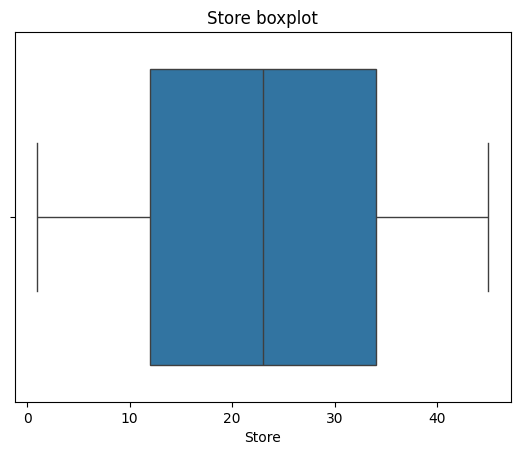

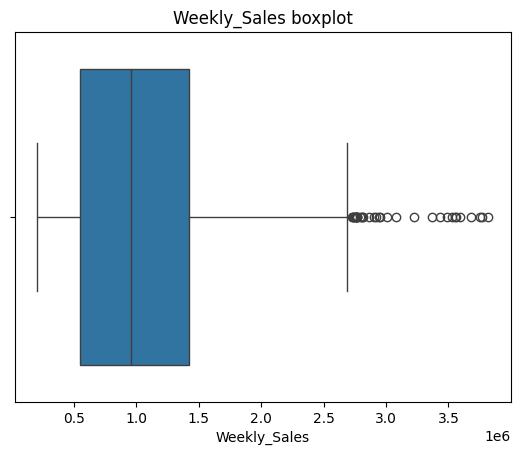

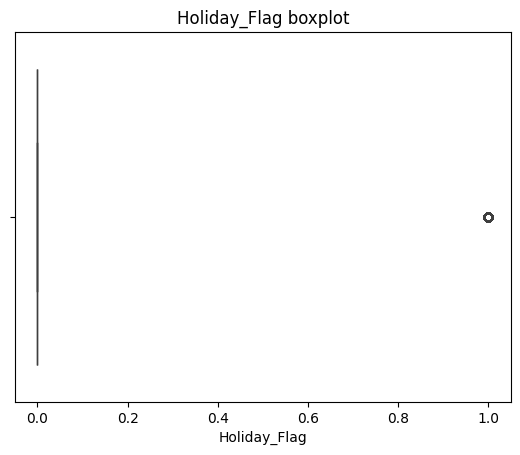

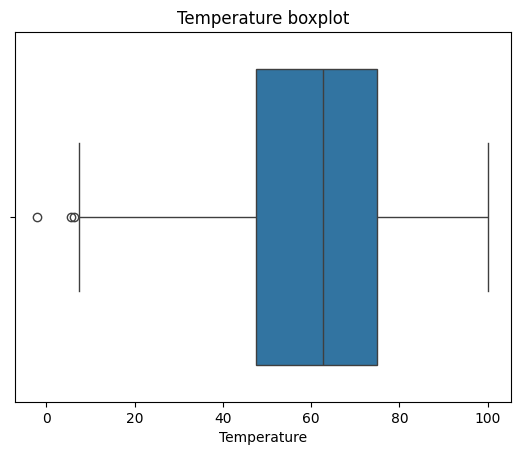

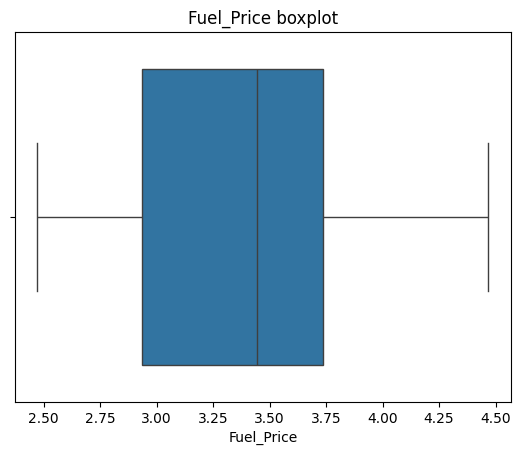

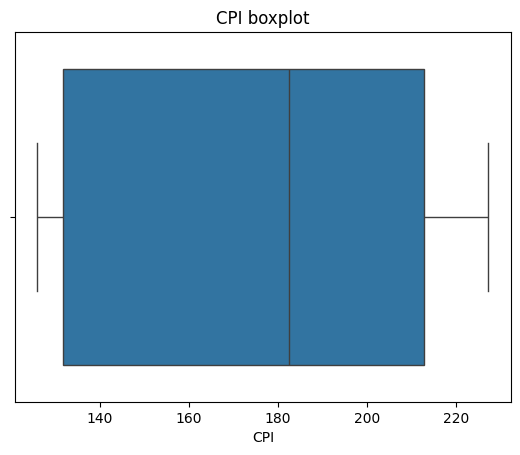

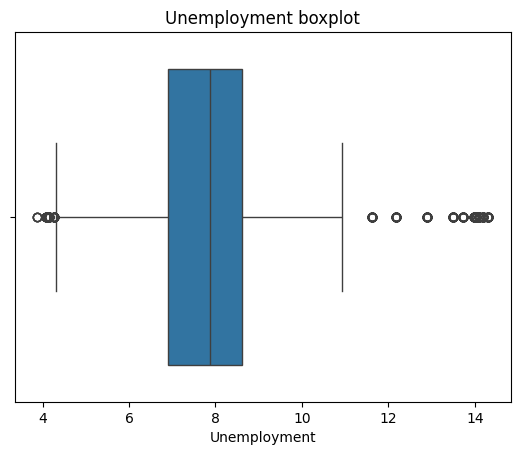

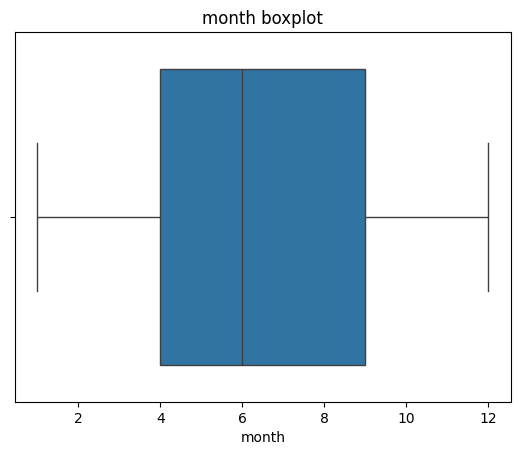

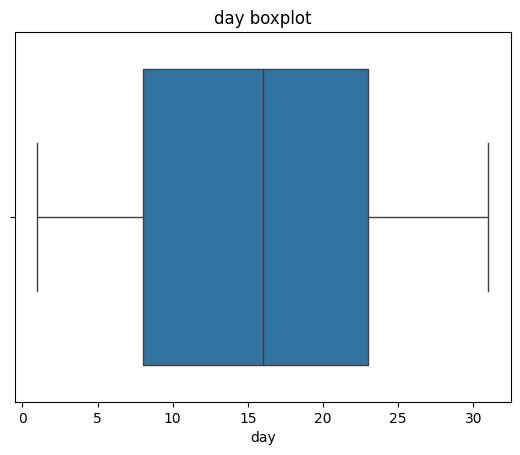

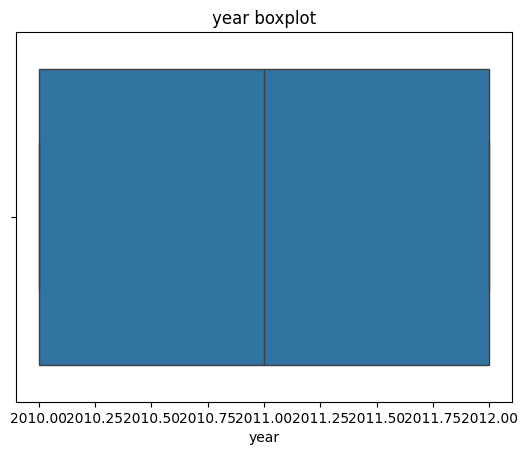

In [13]:
for i in num_df:
    sns.boxplot(x=i,data=df)
    plt.title(f'{i} boxplot')
    plt.show()

which shows there are some outliers in the features

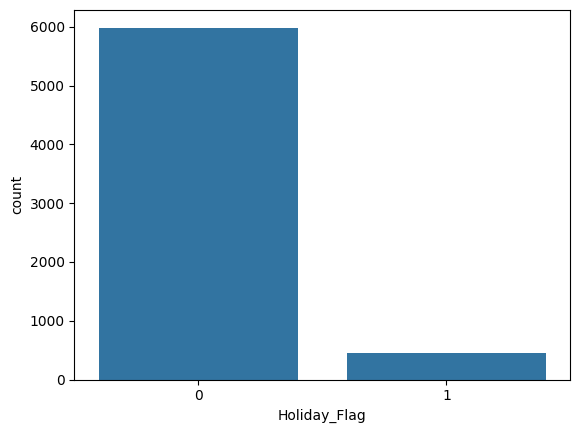

In [14]:
sns.countplot(df,x='Holiday_Flag')
plt.show() 

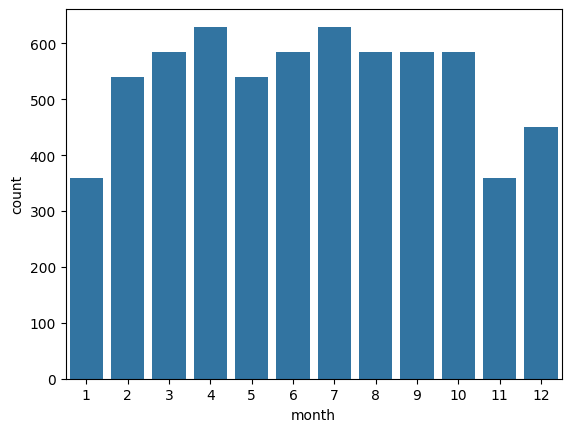

In [15]:
sns.countplot(df,x='month')
plt.show() 

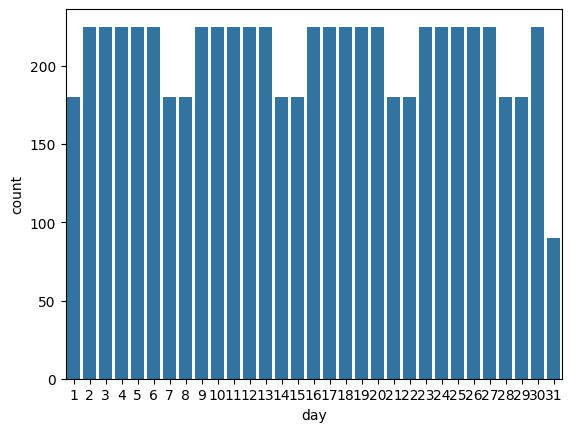

In [16]:
sns.countplot(df,x='day')
plt.show()

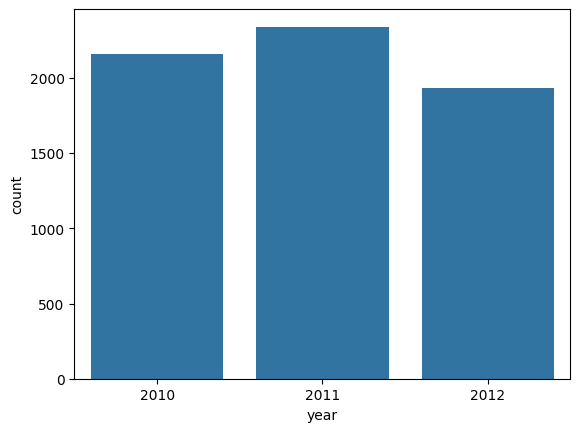

In [17]:
sns.countplot(df,x='year')
plt.show()

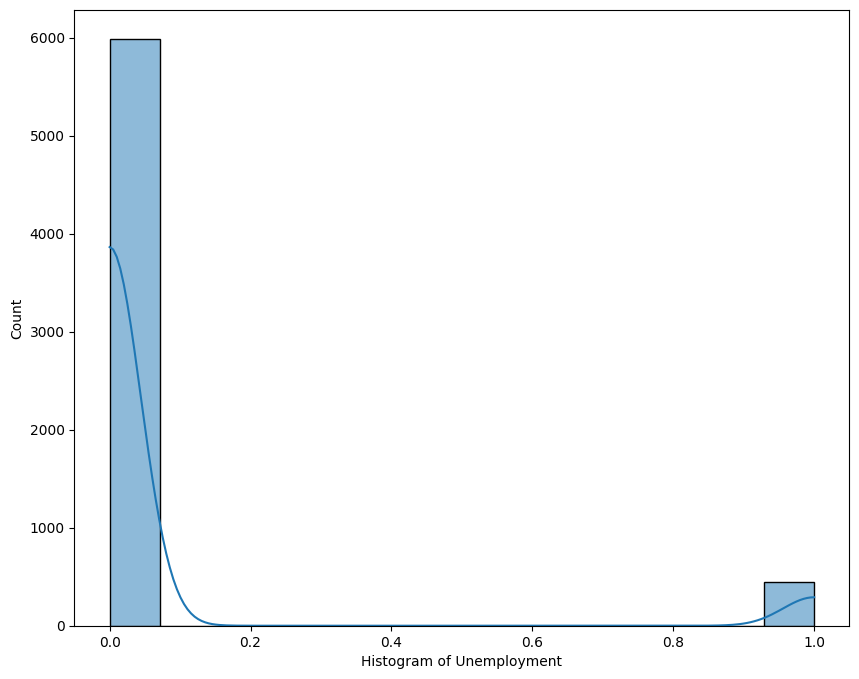

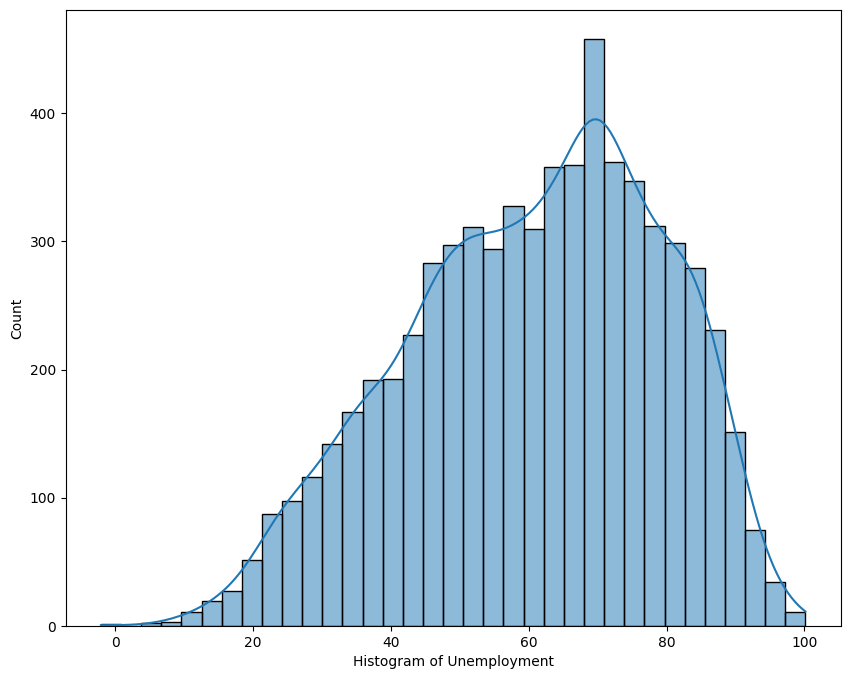

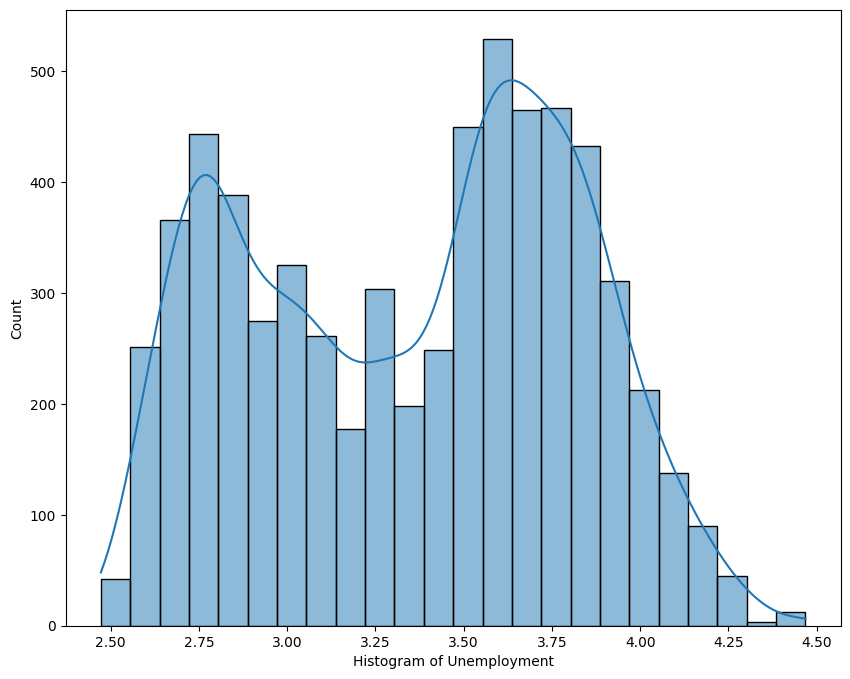

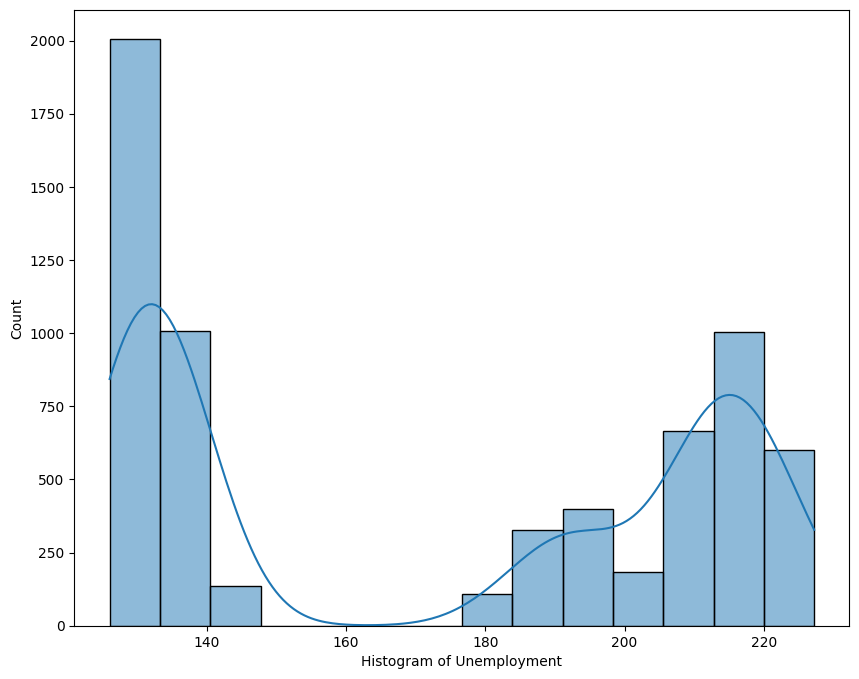

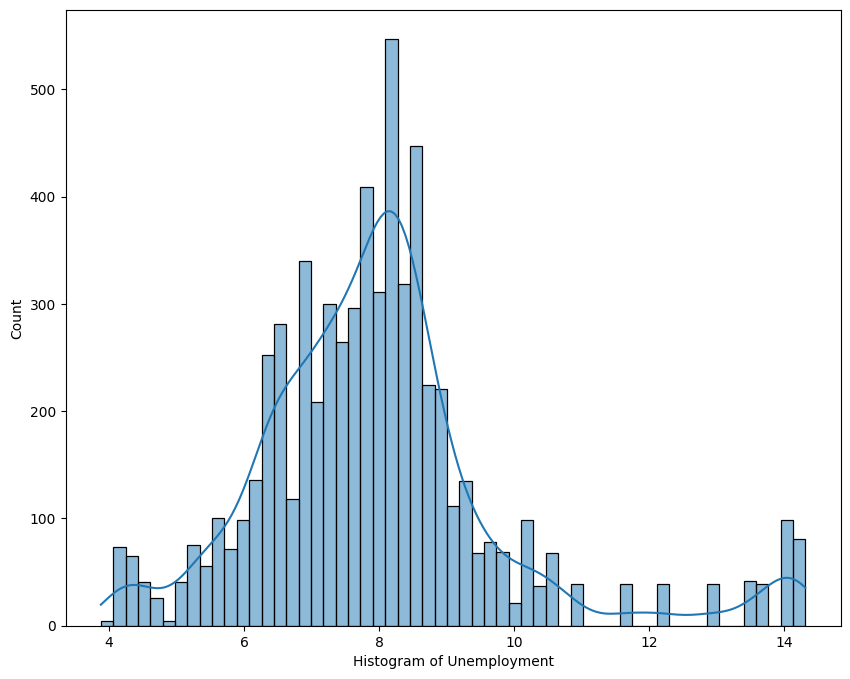

In [18]:
df1=df[['Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment']]
for i in df1:
    plt.figure(figsize=(10,8))
    sns.histplot(df[i],edgecolor='black',kde=True)
    plt.xlabel('Histogram of Unemployment')
    plt.show()

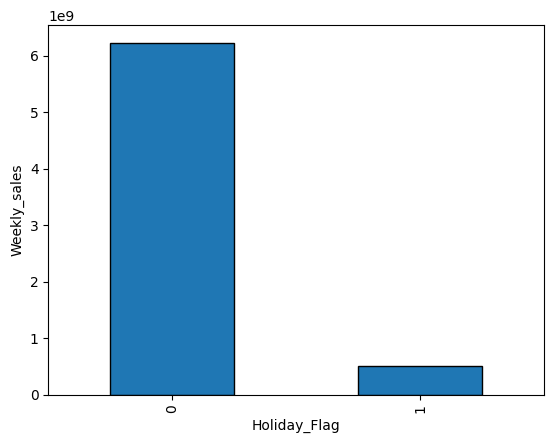

In [19]:
df.groupby(by="Holiday_Flag")["Weekly_Sales"].sum().plot(kind='bar',edgecolor='black')
plt.xlabel('Holiday_Flag')
plt.ylabel('Weekly_sales')
plt.show()

/tmp/ipykernel_17/1932468067.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data = df,


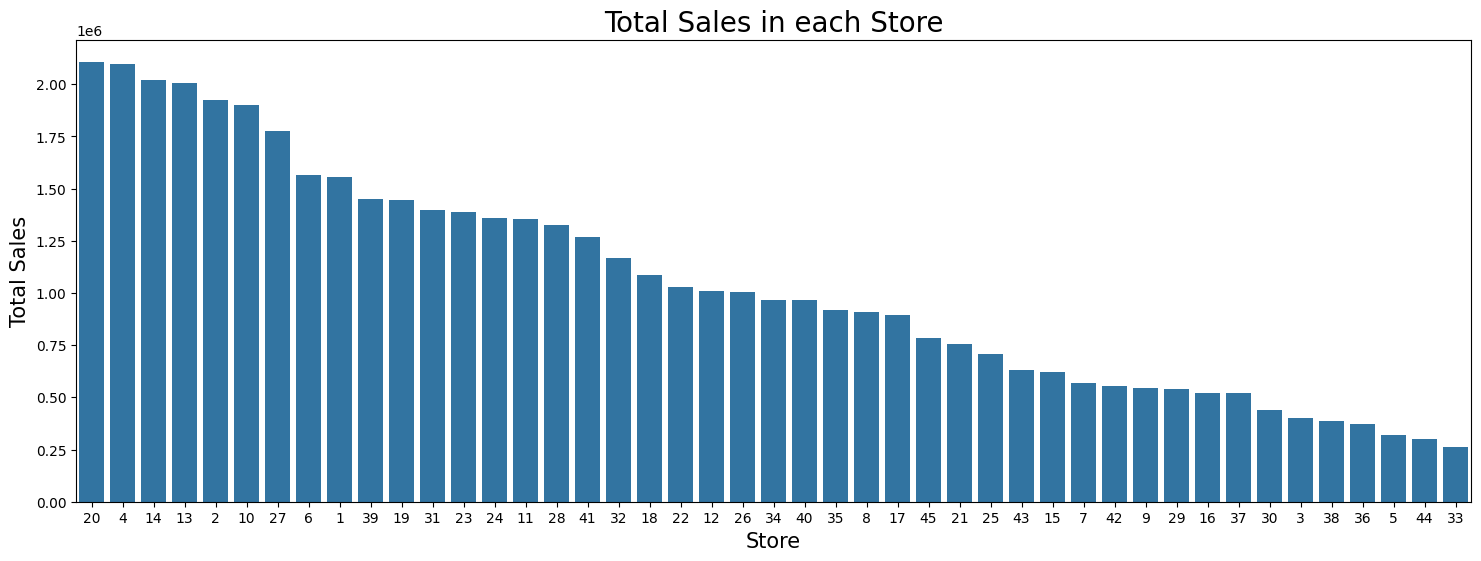

In [20]:
store=df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending = False)
plt.figure(figsize = (18, 6))
sns.barplot(data = df,
            x = 'Store',
            y = 'Weekly_Sales',
            order = store.index,
            ci = False)

# Add labels and title
plt.title('Total Sales in each Store', size = 20)
plt.xlabel('Store', size = 15)
plt.ylabel('Total Sales', size = 15)
plt.show()

In [21]:
best_store = (
    df.groupby("Store")["Weekly_Sales"]
    .sum()
    .idxmax()
)

best_store_sales = (
    df.groupby("Store")["Weekly_Sales"]
    .sum()
    .max()
)

print("Best Performing Store:", best_store)
print("Total Sales:", best_store_sales)

Best Performing Store: 20
Total Sales: 301397792.46


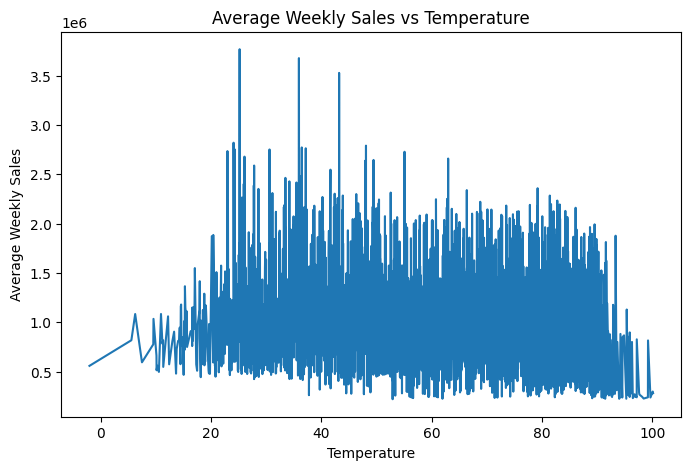

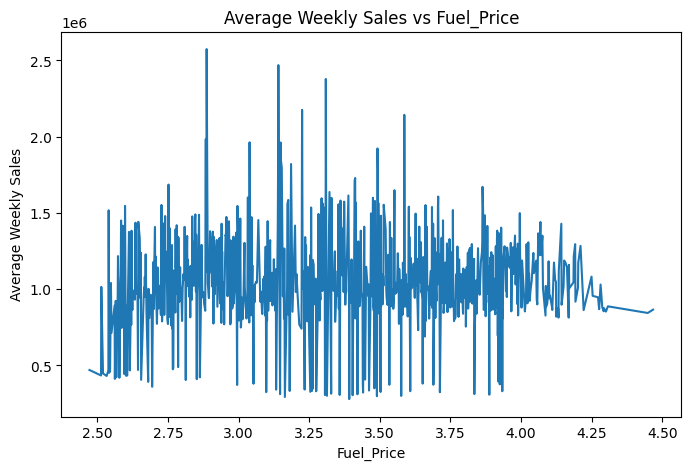

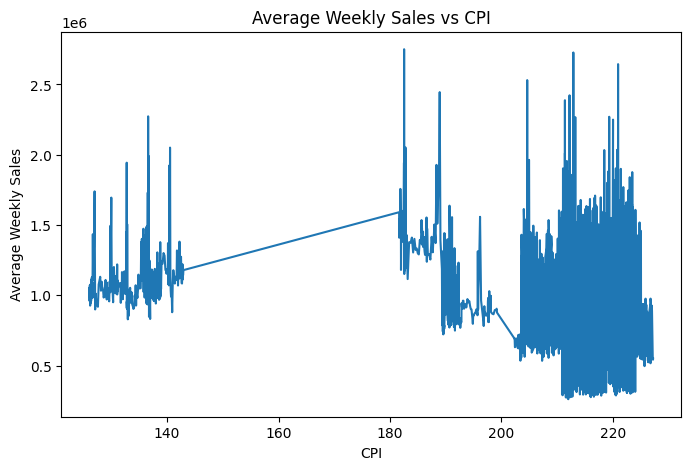

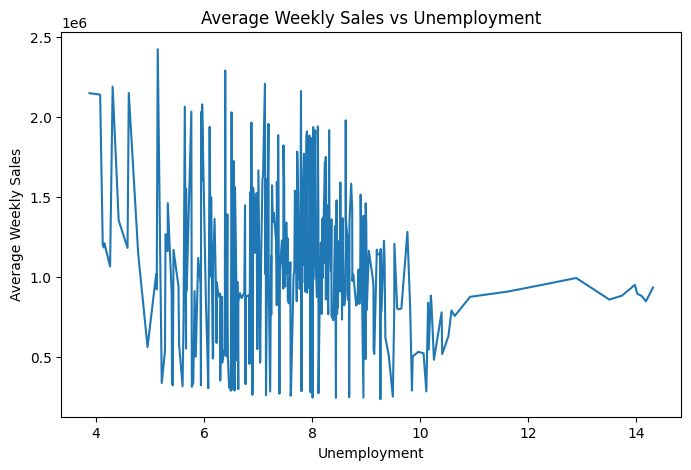

In [22]:
continuous_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]

for col in continuous_cols:
    plt.figure(figsize=(8,5))
    df.groupby(col)["Weekly_Sales"].mean().plot()
    plt.xlabel(col)
    plt.ylabel("Average Weekly Sales")
    plt.title(f"Average Weekly Sales vs {col}")
    plt.show()

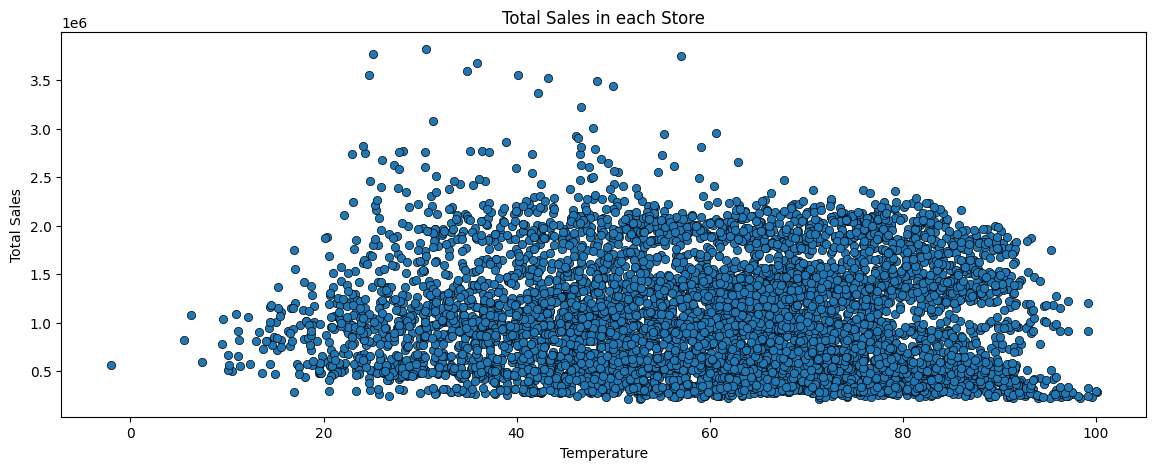

In [23]:
plt.figure(figsize = (14, 5))
sns.scatterplot(data = df,
            x = 'Temperature',
            y = 'Weekly_Sales',edgecolor='black')

# Add labels and title
plt.title('Total Sales in each Store')
plt.xlabel('Temperature')
plt.ylabel('Total Sales')
plt.show()

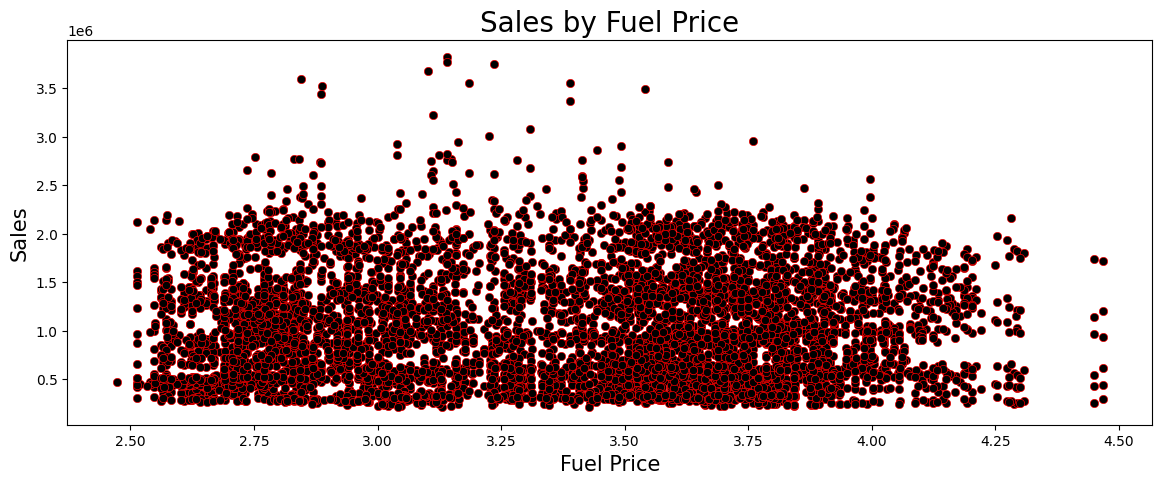

In [24]:
plt.figure(figsize = (14, 5))
sns.scatterplot(data = df,
                x = 'Fuel_Price',
                y = 'Weekly_Sales',
                color = 'black',
                edgecolor = "red")

# Add labels and title
plt.title('Sales by Fuel Price', size = 20)
plt.xlabel('Fuel Price', size = 15)
plt.ylabel('Sales', size = 15)
plt.show()

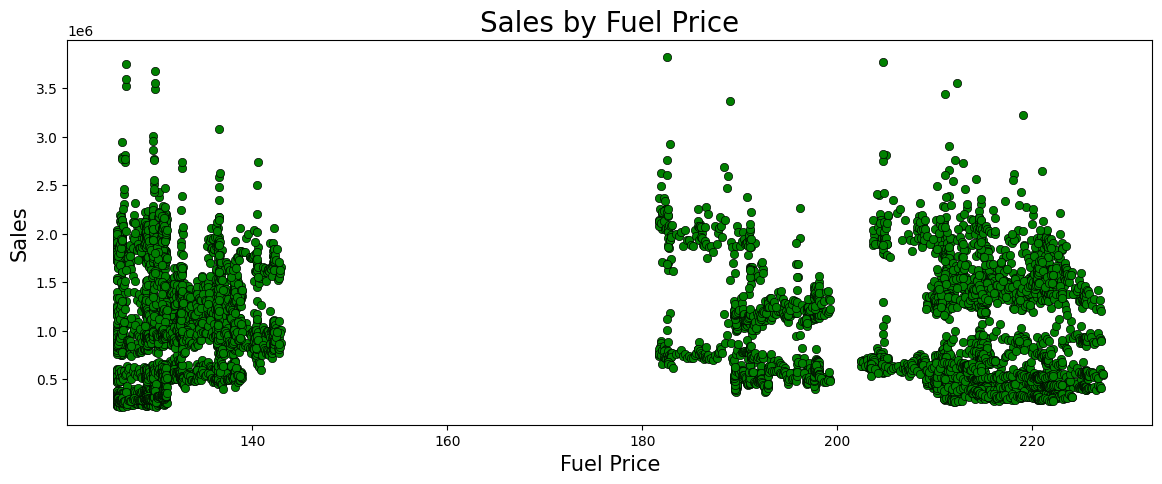

In [25]:
plt.figure(figsize = (14, 5))
sns.scatterplot(data = df,
                x = 'CPI',
                y = 'Weekly_Sales',
                color = 'green',
                edgecolor = "black")

# Add labels and title
plt.title('Sales by Fuel Price', size = 20)
plt.xlabel('Fuel Price', size = 15)
plt.ylabel('Sales', size = 15)
plt.show()

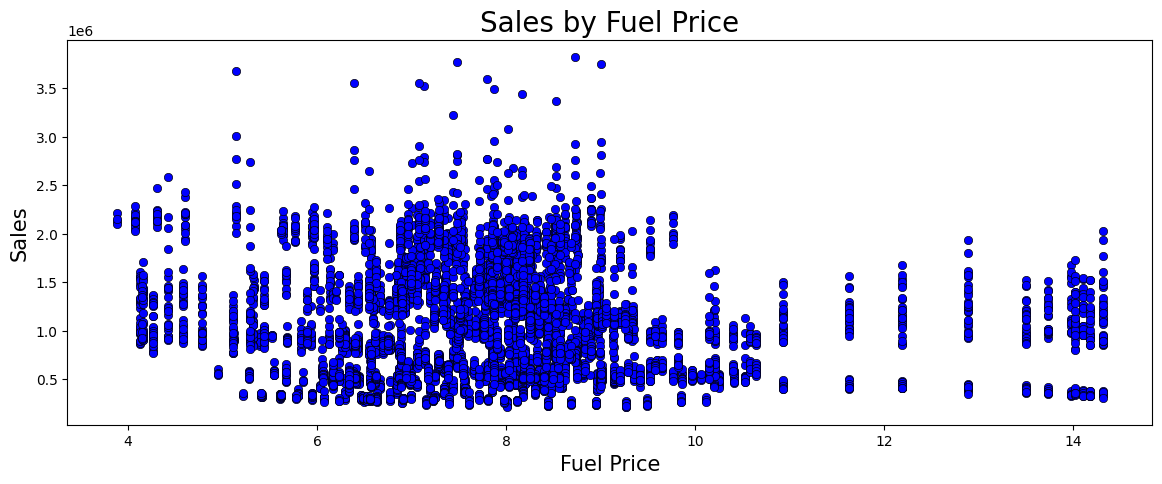

In [26]:
plt.figure(figsize = (14, 5))
sns.scatterplot(data = df,
                x = 'Unemployment',
                y = 'Weekly_Sales',
                color = 'blue',
                edgecolor = "black")

# Add labels and title
plt.title('Sales by Fuel Price', size = 20)
plt.xlabel('Fuel Price', size = 15)
plt.ylabel('Sales', size = 15)
plt.show()

## Time Series Analysis

In [27]:
month_wise_sales = (
    df.groupby("month", as_index=False)["Weekly_Sales"]
    .sum()
)
year_wise_sales = (
    df.groupby("year", as_index=False)["Weekly_Sales"]
    .sum()
)

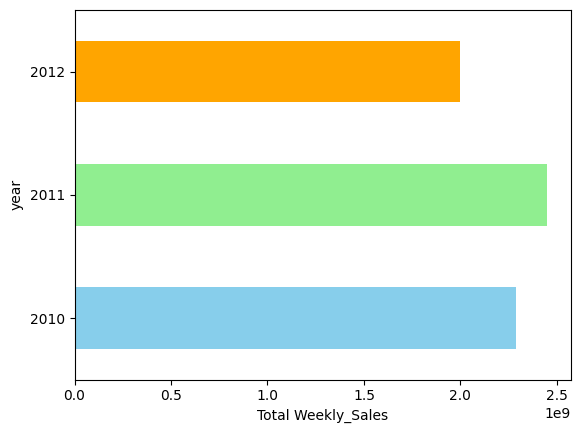

In [28]:
fig , ax = plt.subplots()
colors = ["skyblue", "lightgreen", "orange"]

df.groupby(by="year")["Weekly_Sales"].sum().plot(kind="barh",ax=ax, color = colors)
ax.set_xlabel("Total Weekly_Sales")
plt.show()

**Total sales in 2011 were the highest, with 2,448,200,007$.**

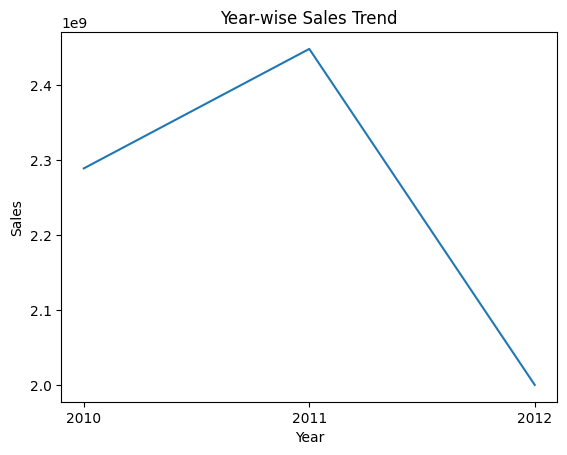

In [29]:
plt.figure()
plt.plot(
    year_wise_sales["year"].astype(str),
    year_wise_sales["Weekly_Sales"]
)
plt.title("Year-wise Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

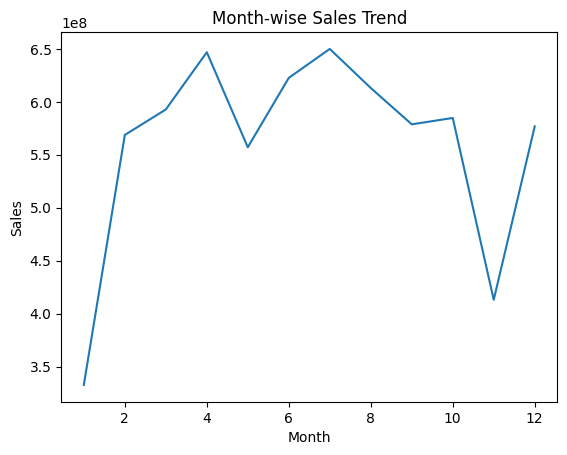

In [30]:
plt.figure()
plt.plot(month_wise_sales["month"], month_wise_sales["Weekly_Sales"])
plt.title("Month-wise Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

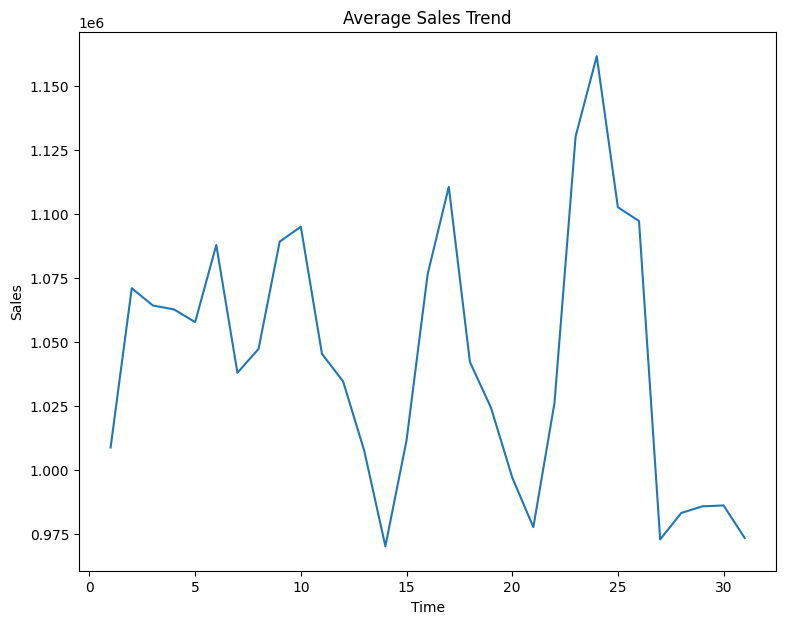

In [31]:
avg_daily_sales = (
    df.groupby("day")["Weekly_Sales"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(9,7))
plt.plot(avg_daily_sales.index, avg_daily_sales.values)
plt.title("Average Sales Trend")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()

/tmp/ipykernel_17/1601141045.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data = df,


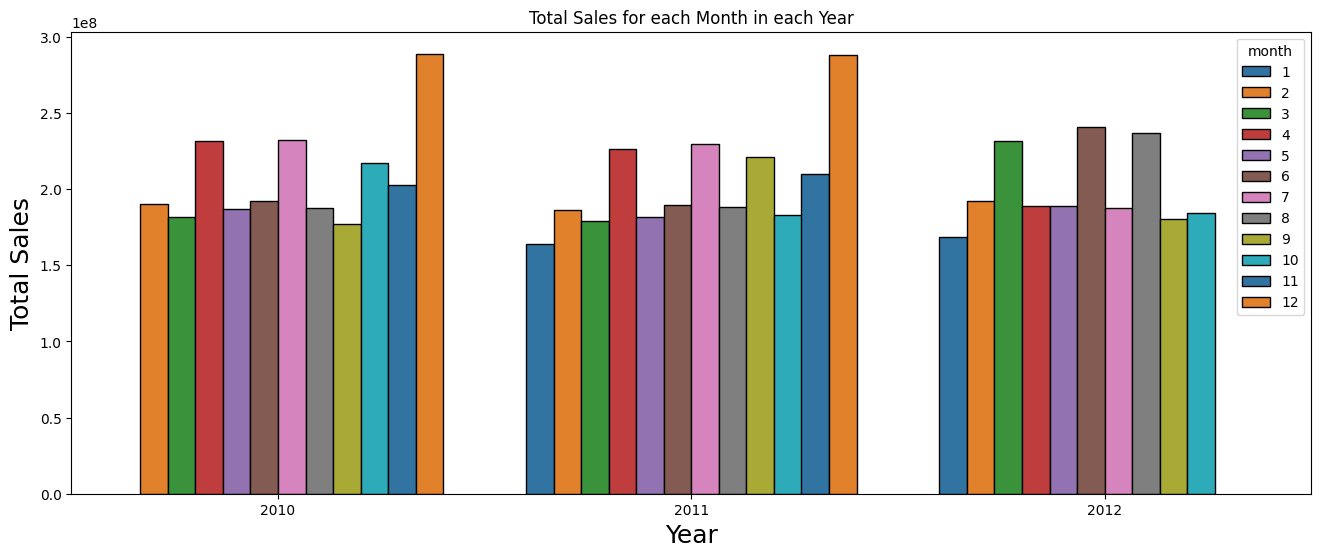

In [32]:
plt.figure(figsize = (16, 6))
sns.barplot(data = df,
            x = 'year',
            y = 'Weekly_Sales',
            hue = 'month',
            estimator = np.sum,
            palette='tab10',
            edgecolor='black',
            ci = False)

# Add labels and title
plt.title('Total Sales for each Month in each Year')
plt.xlabel('Year', size = 18)
plt.ylabel('Total Sales', size = 18)

plt.show()

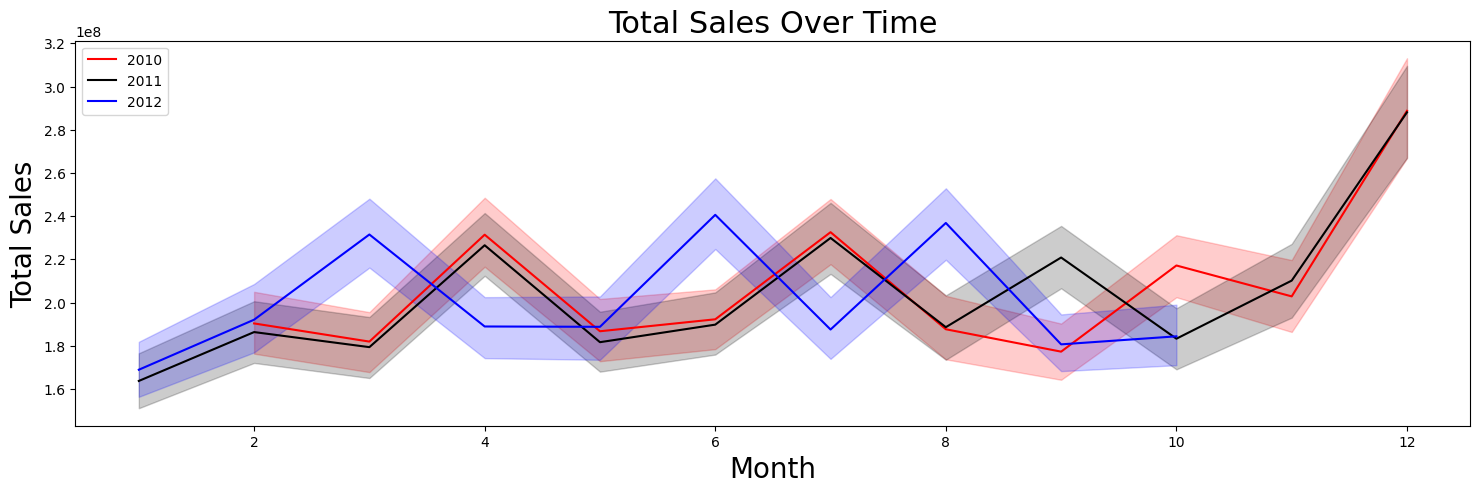

In [33]:
years = ['2010', '2011', '2012']
colors = ['red', 'black', 'blue']

plt.figure(figsize = (18, 5))
for i, year in enumerate(years):
    sns.lineplot(data = df[df['year'] == int(year)],
                 x = 'month',
                 y = 'Weekly_Sales',
                 estimator = np.sum,
                 color = colors[i],
                 label = year)

# Add labels and title
plt.title(f'Total Sales Over Time', size = 22)
plt.xlabel('Month', size = 20)
plt.ylabel('Total Sales', size = 20)

# Add a legend
plt.legend()

# Show the plot
plt.show()

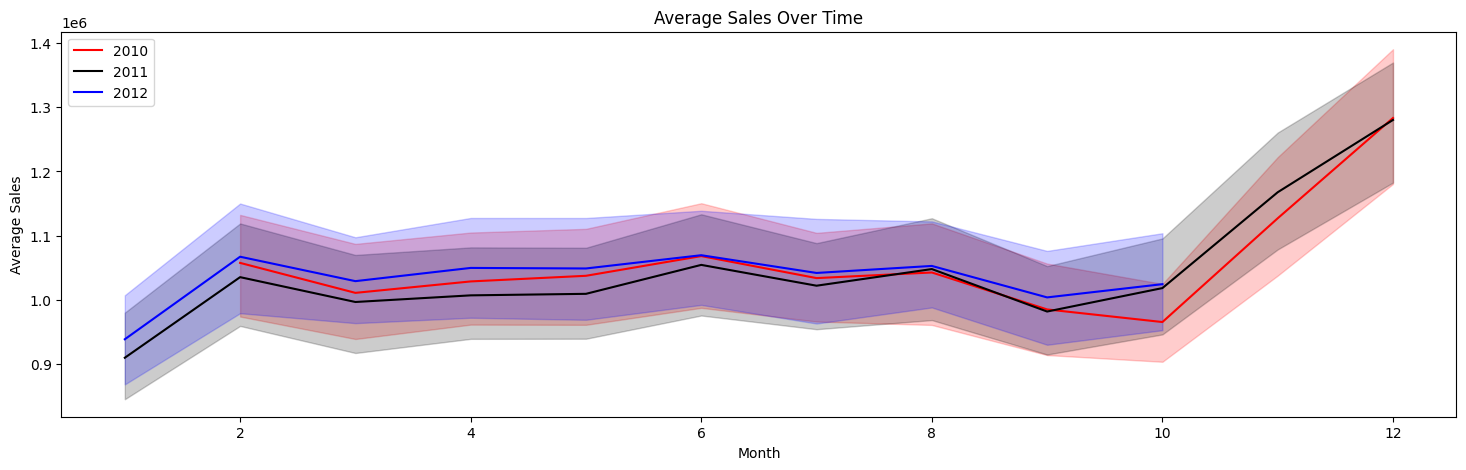

In [34]:
years = ['2010', '2011', '2012']
colors = ['red', 'black', 'blue']

plt.figure(figsize = (18, 5))
for i, year in enumerate(years):
    sns.lineplot(data = df[df['year'] == int(year)],
                 x = 'month',
                 y = 'Weekly_Sales',
                 estimator = np.mean,
                 color = colors[i],
                 label = year)

# Add labels and title
plt.title(f'Average Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Average Sales')

# Add a legend
plt.legend()

# Show the plot
plt.show()

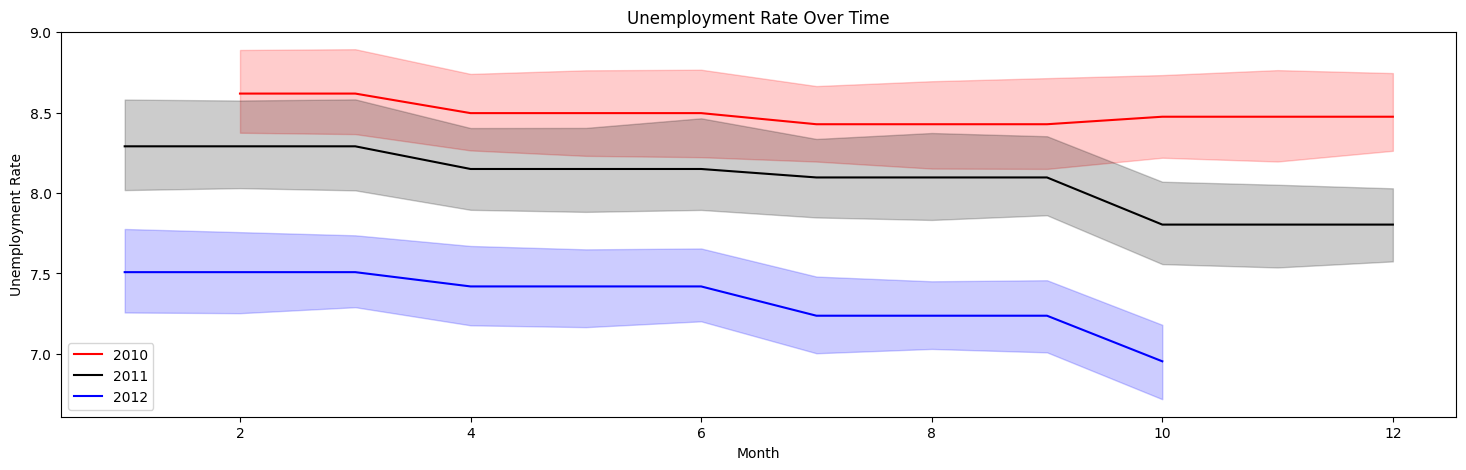

In [35]:
plt.figure(figsize = (18, 5))
for i, year in enumerate(years):
    sns.lineplot(data = df[df['year'] == int(year)],
                 x = 'month',
                 y = 'Unemployment',
                 estimator = np.mean,
                 color = colors[i],
                 label = year)

# Add labels and title
plt.title(f'Unemployment Rate Over Time')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate')

# Add a legend
plt.legend()

# Show the plot
plt.show()

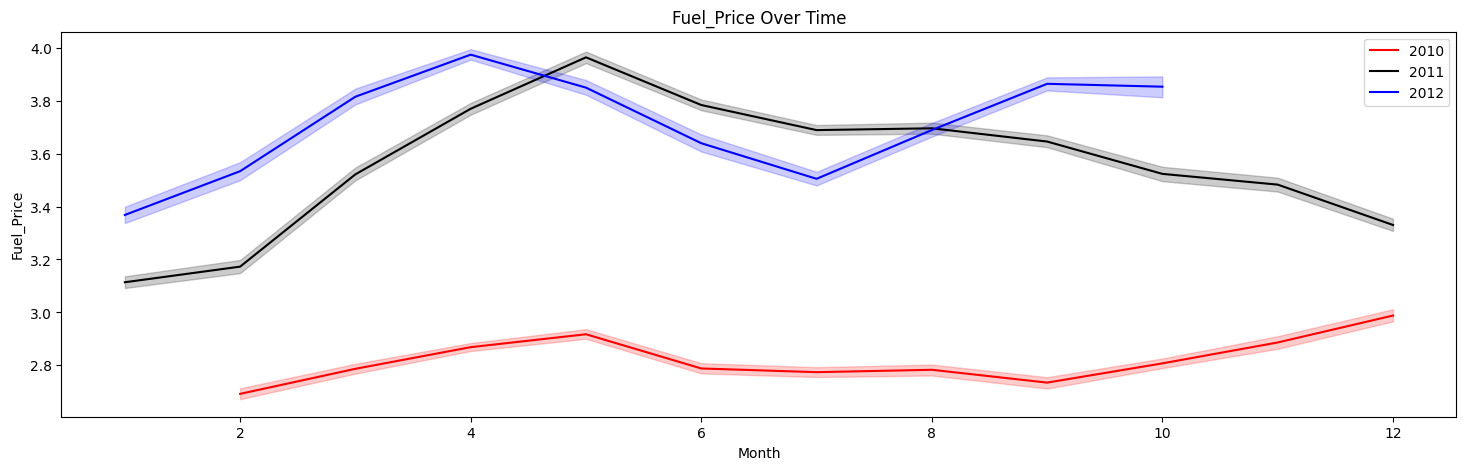

In [36]:
plt.figure(figsize = (18, 5))
for i, year in enumerate(years):
    sns.lineplot(data = df[df['year'] == int(year)],
                 x = 'month',
                 y = 'Fuel_Price',
                 estimator = np.mean,
                 color = colors[i],
                 label = year)

# Add labels and title
plt.title(f'Fuel_Price Over Time')
plt.xlabel('Month')
plt.ylabel('Fuel_Price')

# Add a legend
plt.legend()

# Show the plot
plt.show()

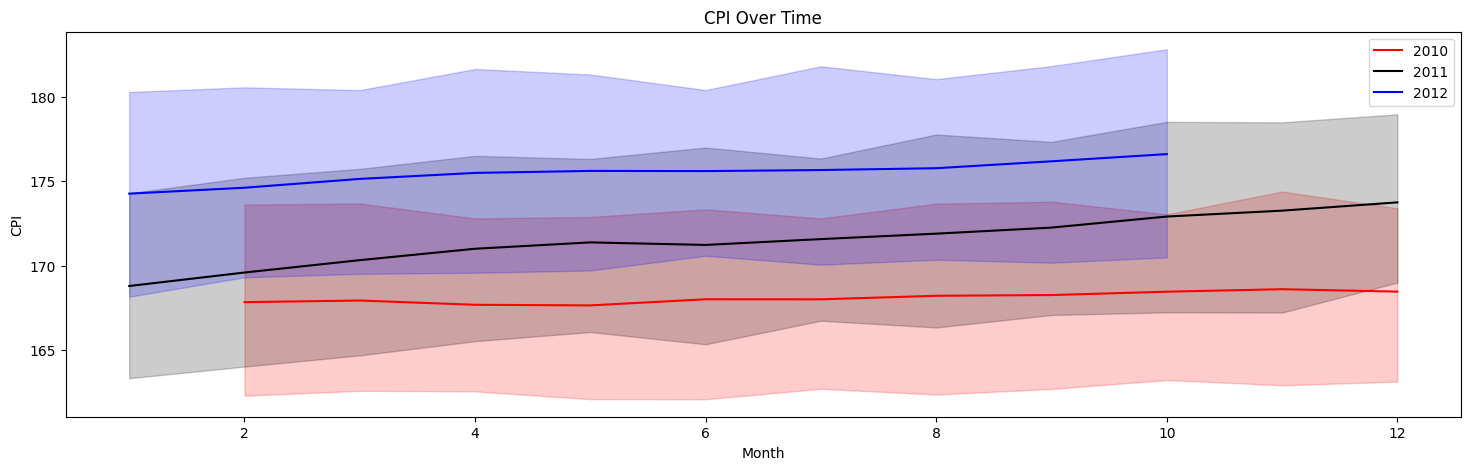

In [37]:
plt.figure(figsize = (18, 5))
for i, year in enumerate(years):
    sns.lineplot(data = df[df['year'] == int(year)],
                 x = 'month',
                 y = 'CPI',
                 estimator = np.mean,
                 color = colors[i],
                 label = year)

# Add labels and title
plt.title(f'CPI Over Time')
plt.xlabel('Month')
plt.ylabel('CPI')

# Add a legend
plt.legend()

# Show the plot
plt.show()

**If you found this notebook useful or informative, an upvote would be appreciated.**